# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement

Write the problem statement and objectives here


### Data Dictionary

Mention the data dictionary here

### Let us start by importing the required libraries

In [ ]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Understanding the structure of the data

In [ ]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Write your code here to read the data
folder_location = "/content/drive/MyDrive/AIML/UT Austin PGP/Python/Final Project/"
foodhub_order_file = "foodhub_order.csv"
df_foodhub_order = pd.read_csv(folder_location+foodhub_order_file)

In [ ]:
# Write your code here to view the first 5 rows
df_foodhub_order.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Write your code here
shape_df = df_foodhub_order.shape
print("Number of rows: ",shape_df[1], "And number of columns:",shape_df[0])

Number of rows:  9 And number of columns: 1898


#### Observations:
Number of rows:  9 And number of columns: 1898

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Write your code here
print(df_foodhub_order.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB
None


#### Observations:


```
 #   Column                 Dtype  
---  ------                 -----  
 0   order_id               int64  
 1   customer_id            int64  
 2   restaurant_name        object
 3   cuisine_type           object
 4   cost_of_the_order      float64
 5   day_of_the_week        object
 6   rating                 object
 7   food_preparation_time  int64  
 8   delivery_time          int64  
```



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Write your code here
df_foodhub_order.replace(r'^\s*$', np.nan, regex=True)
if (df_foodhub_order.isnull().any(axis=None)):
    print("There are missing values in the dataset")
    print("Missing Null Values Column-wise: \n",df_foodhub_order.isnull().sum())
else:
    print("There are no missing values in the dataset")

There are no missing values in the dataset


#### Observations:
There are no missing values in the dataset

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Write your code here
print("Minimum time it takes for food to be prepared once the order is placed:",df_foodhub_order["food_preparation_time"].min())
print("Average time it takes for food to be prepared once the order is placed:",round(df_foodhub_order["food_preparation_time"].mean(),2))
print("Maximum time it takes for food to be prepared once the order is placed:",df_foodhub_order["food_preparation_time"].max())

Minimum time it takes for food to be prepared once the order is placed: 20
Average time it takes for food to be prepared once the order is placed: 27.37
Maximum time it takes for food to be prepared once the order is placed: 35


#### Observations:


1.   Minimum time it takes for food to be prepared once the order is placed: 20
2.   Average time it takes for food to be prepared once the order is placed: 27.37
3.   Maximum time it takes for food to be prepared once the order is placed: 35



### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Write the code here
print("Number of orders are not rated: ",(df_foodhub_order['rating']=="Not given").sum())

Number of orders are not rated:  736


#### Observations:
736 orders are not rated.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
# Write the code here

# General Analysis

# Creating a common function to find the value count of any column
def counts_data(column_name):
  res = df_foodhub_order[column_name].value_counts()
  return res

print("How many times each restaurant has received ordered:\n",counts_data('restaurant_name'))
print("What is the order count for each cuisine type:\n",counts_data('cuisine_type'))
print("Between Weekday and weekend, what is the order count", counts_data('day_of_the_week'))
print("Which are the restaurant received order more than once:",df_foodhub_order['restaurant_name'].value_counts().reset_index().query('count > 1'))

How many times each restaurant has received ordered:
 restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Rye House                      1
Hiroko's Place                 1
Frank Restaurant               1
Sarabeth's West                1
'wichcraft                     1
Name: count, Length: 178, dtype: int64
What is the order count for each cuisine type:
 cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64
Between Weekday and weekend, what is the order count day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64
Which 

In [ ]:
# Central Tendency Analysis - Numerical data
print("Average cost of the order:",round(df_foodhub_order["cost_of_the_order"].mean(),2))
print("Median cost of the order:",df_foodhub_order["cost_of_the_order"].median())
print("Average food preparation time:",round(df_foodhub_order["food_preparation_time"].mean(),2))
print("Median food preparation time:",df_foodhub_order["food_preparation_time"].median())
print("Average delivery time:",round(df_foodhub_order["delivery_time"].mean(),2))
print("Median delivery time:",df_foodhub_order["delivery_time"].median())

Average cost of the order: 16.5
Median cost of the order: 14.14
Average food preparation time: 27.37
Median food preparation time: 27.0
Average delivery time: 24.16
Median delivery time: 25.0


### Observations:

* Average cost of the order: 16.5
* Median cost of the order: 14.14
* Average food preparation time: 27.37
* Median food preparation time: 27.0
* Average delivery time: 24.16
* Median delivery time: 25.0

In [ ]:
# Central Tendency Analysis - Categorical data
print("Most frequently ordered resturant:",df_foodhub_order["restaurant_name"].mode())
print("Most frequently ordered cuisine_type",df_foodhub_order["cuisine_type"].mode())
print("Most frequently ordered time of the week:",df_foodhub_order["day_of_the_week"].mode())

Most frequently ordered resturant: 0    Shake Shack
Name: restaurant_name, dtype: object
Most frequently ordered cuisine_type 0    American
Name: cuisine_type, dtype: object
Most frequently ordered time of the week: 0    Weekend
Name: day_of_the_week, dtype: object


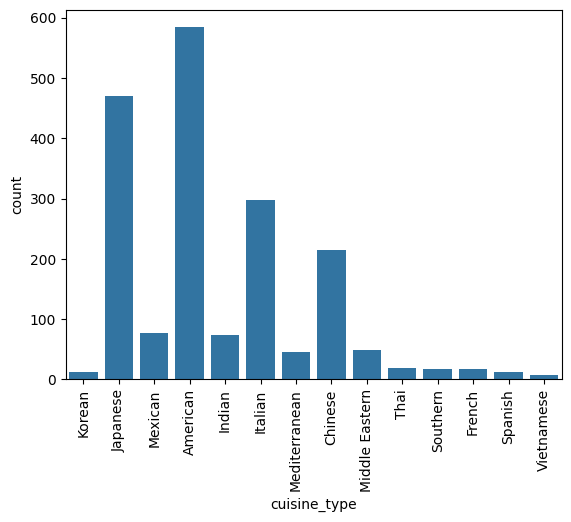

In [ ]:
# Graphical Representations:

sns.countplot(x = 'cuisine_type', data = df_foodhub_order)
plt.xticks(rotation=90)
plt.show()

Observations:


*   American food is ordered highest
*   Japanese food is the second highest in-demand cuisine
*   Italian cuisine comes 3rd on the highest ordered cuisine list.




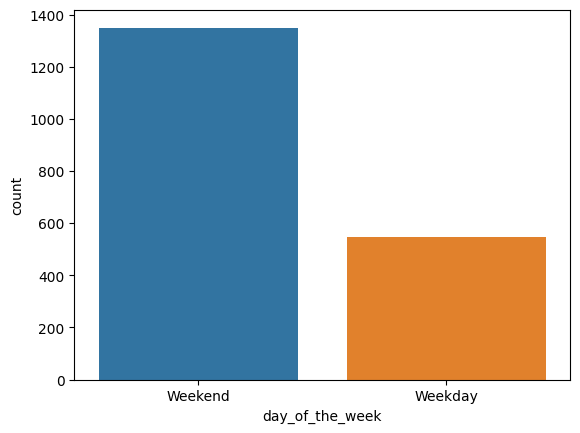

In [ ]:
sns.countplot(x = 'day_of_the_week', data = df_foodhub_order, hue = 'day_of_the_week');

### Observations:
Food ordered during weekend is significantly more than food ordered in weekdays.


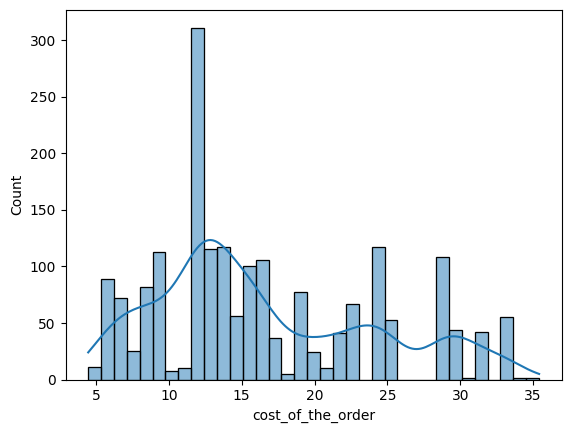

In [ ]:
sns.histplot(data = df_foodhub_order, x ='cost_of_the_order', kde=True, bins=35);

### Observations:
Foods price around $12-$15 are in high demand.

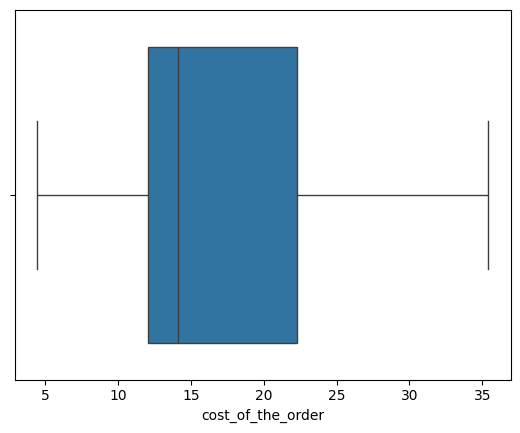

In [ ]:
sns.boxplot(data = df_foodhub_order, x ='cost_of_the_order');

### Observations:


*   Half of the orders cost less than 15 USD
*   Most customers are orddering between range of 12- 23 USD
*   This is right-skewed distribution as few customers placed costly orders but not many.



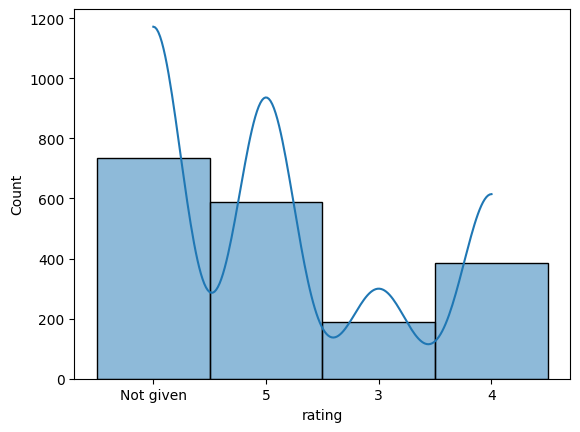

In [ ]:
sns.histplot(data = df_foodhub_order, x ='rating', kde=True);

### Observations:

Majority of the people are not giving any rating to the orders



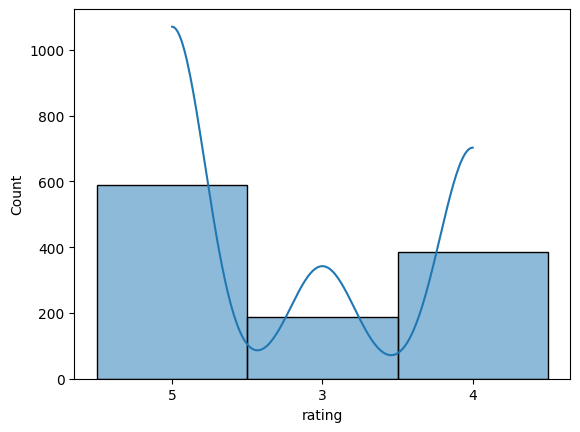

In [ ]:
df_rating = df_foodhub_order[df_foodhub_order['rating'] != 'Not given']
sns.histplot(data = df_rating, x ='rating', kde=True);

### Observations:
Most of the people are giving highest rating (5), followed by rating 4, out of the people who rated their order.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Write the code here
print(df_foodhub_order['restaurant_name'].value_counts().head())

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


#### Observations:

Top 5 most frequent ordered restaurants are:                 

*   Shake Shack
*   The Meatball Shop
*   Blue Ribbon Sushi
*   Blue Ribbon Fried Chicken
*   Parm

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
df_weekend = df_foodhub_order[df_foodhub_order['day_of_the_week'] == 'Weekend']
print(df_weekend['cuisine_type'].value_counts().head(1))

cuisine_type
American    415
Name: count, dtype: int64


#### Observations:
Maximum ordered cuisine type is **American**





### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
df_cost_more_than_20 = df_foodhub_order[df_foodhub_order['cost_of_the_order'] > 20]
percentage_cost_more_than_20 = (df_cost_more_than_20.shape[0]/df_foodhub_order.shape[0])*100
print(f"Percentage of orders cost more than 20 dollars: {round(percentage_cost_more_than_20,2)}%")

Percentage of orders cost more than 20 dollars: 29.24%


#### Observations:
Percentage of orders cost more than 20 dollars: 29.24%

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
print("Mean order delivery time:",round(df_foodhub_order["delivery_time"].mean(),2))

Mean order delivery time: 24.16


#### Observations:
Mean order delivery time: 24.16

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
print("Top 3 most frequent customers with the number of orders they placed:\n",df_foodhub_order['customer_id'].value_counts().head(3))

Top 3 most frequent customers with the number of orders they placed:
 customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations:
Top 3 most frequent customers with the number of orders they placed:

1.   52832 - 13 times
2.   47440 - 10 times
3.   83287 - 9 times

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


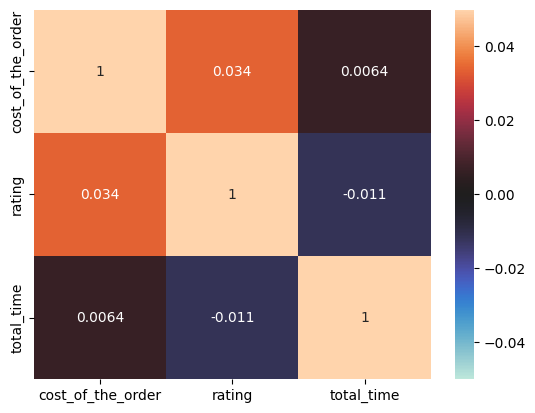

In [ ]:
df_foodhub_order['rating'] = df_foodhub_order['rating'].replace("Not given",np.nan)
df_foodhub_order['rating'] = pd.to_numeric(df_foodhub_order['rating'], errors='coerce')
df_foodhub_order['total_time'] = df_foodhub_order['food_preparation_time'] + df_foodhub_order['delivery_time']
sns.heatmap(data=df_foodhub_order[['cost_of_the_order','rating','total_time']].corr(), cmap='icefire', annot=True, vmin=-0.05, vmax=0.05);

### Observations:
No strong linear relationships

<Axes: xlabel='rating', ylabel='cost_of_the_order'>

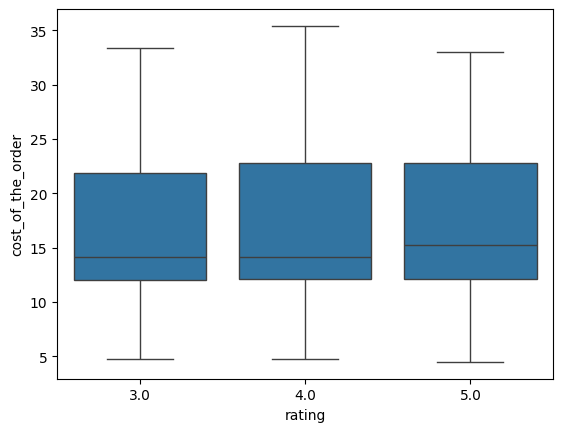

In [ ]:
sns.boxplot(data = df_foodhub_order, x='rating', y='cost_of_the_order')

### Observations:
Customers are focusing more on the better quality food, ready to pay more price for it.

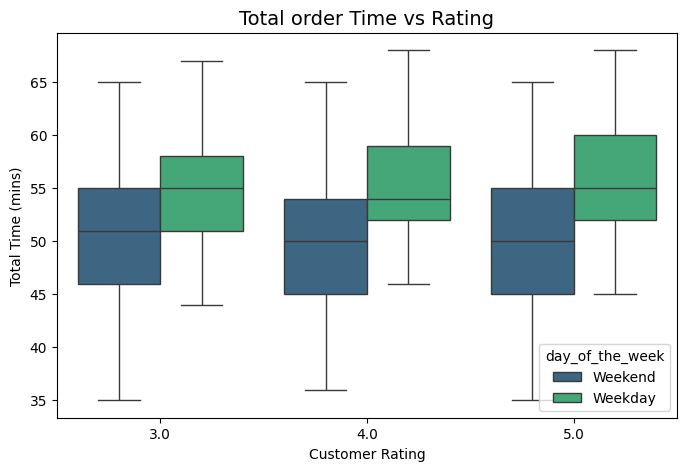

In [ ]:
df_foodhub_order['total_time'] = df_foodhub_order['food_preparation_time'] + df_foodhub_order['delivery_time']

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_foodhub_order,
    x='rating',
    y='total_time',
    palette='viridis',
    hue='day_of_the_week',
    width=0.8
)
plt.title('Total order Time vs Rating', fontsize=14)
plt.xlabel('Customer Rating')
plt.ylabel('Total Time (mins)')
plt.show()

### Observations:
Customers are not giving bad rating if the delivery takes more time.

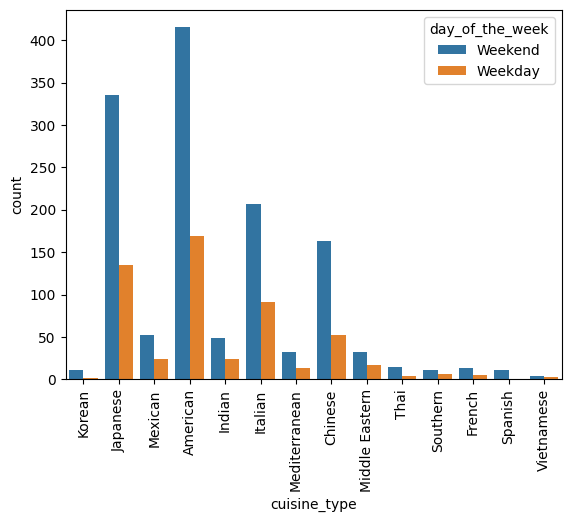

In [ ]:
sns.countplot(x = 'cuisine_type', data = df_foodhub_order, hue = 'day_of_the_week')
plt.xticks(rotation=90)
plt.show()

### Observations:
*  Weekends drive major revenue spikes
*  Focus cuisines for business: American , Japanese , Italian are most ordered cuisines.

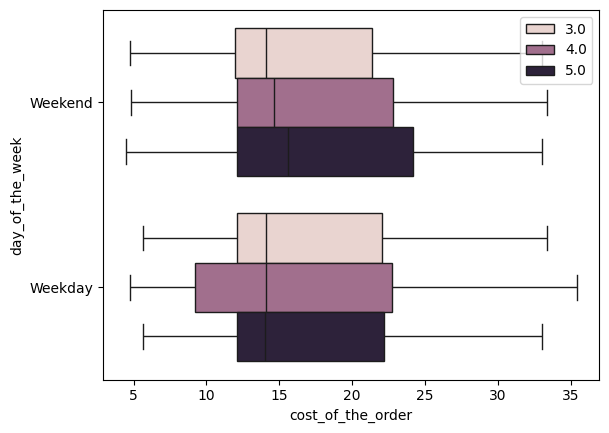

In [ ]:
sns.boxplot(data=df_foodhub_order, x='cost_of_the_order', y='day_of_the_week', hue='rating')
plt.legend(loc='upper right')
plt.show()

### Observations:

*  Higher ratings (5.0) tend to have slightly higher order values
*  Weekday orders have slightly more consistent pricing
* People are buying more cheap priced food during weekdays than weekends
* People are buying slightly more expensive foods during weekends.

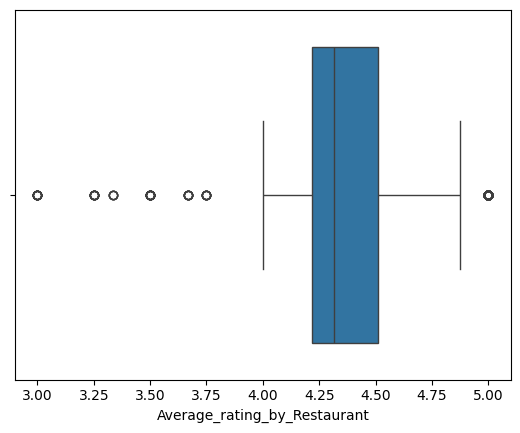

In [ ]:
df_foodhub_order['Average_rating_by_Restaurant'] = df_foodhub_order.groupby('restaurant_name')['rating'].transform('mean')
sns.boxplot(data=df_foodhub_order, x='Average_rating_by_Restaurant')
plt.show()

In [ ]:
# Restaurants with below 4.0 Average rating
print(df_foodhub_order[df_foodhub_order['Average_rating_by_Restaurant'] < 3.8]['restaurant_name'].value_counts())

restaurant_name
Cafeteria                     9
Waverly Diner                 7
Sarabeth's East               7
Pylos                         5
Blue Ribbon Brooklyn          4
The Odeon                     3
Go! Go! Curry!                3
Don's Bogam BBQ & Wine Bar    3
Terakawa Ramen                3
Byblos Restaurant             2
brgr                          2
Haveli Indian Restaurant      2
Pepe Giallo                   1
Woorijip                      1
Sushi Choshi                  1
Nha Trang One                 1
Sarabeth's West               1
Name: count, dtype: int64


Observations:
Below Restaurants are having average rating less than 4.0:


```
Cafeteria                     9
Waverly Diner                 7
Sarabeth's East               7
Pylos                         5
Blue Ribbon Brooklyn          4
The Odeon                     3
Go! Go! Curry!                3
Don's Bogam BBQ & Wine Bar    3
Terakawa Ramen                3
Byblos Restaurant             2
brgr                          2
Haveli Indian Restaurant      2
Pepe Giallo                   1
Woorijip                      1
Sushi Choshi                  1
Nha Trang One                 1
Sarabeth's West               1
```



### Observations:

*  Most restaurants = very good (4.2–4.5)
*  Few bad ones = dragging the average down
*  Very few perfect ones = top performers

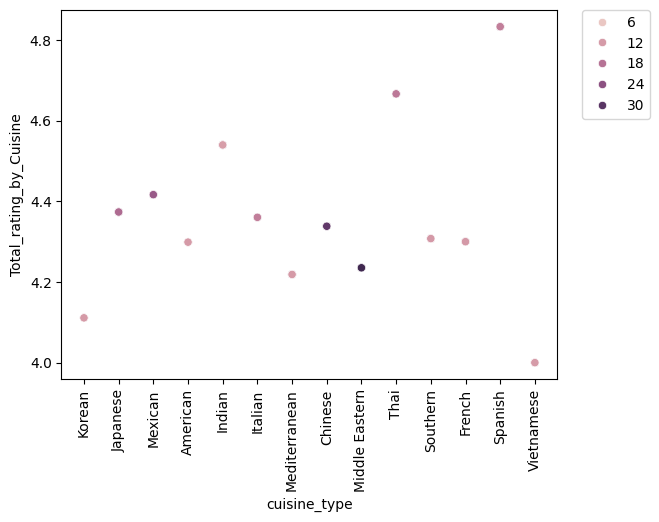

In [ ]:
df_foodhub_order['Total_rating_by_Cuisine'] = df_foodhub_order.groupby('cuisine_type')['rating'].transform('mean')
sns.scatterplot(data=df_foodhub_order, y='Total_rating_by_Cuisine', x='cuisine_type', hue='cost_of_the_order')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

### Observations:

*  Highest satisfaction: Spanish, Thai, Indian
*  Most consistent: Mexican, Japanese, Italian
*  Improvement needed: Vietnamese, Korean, Mediterranean
*  Scale-quality gap: Chinese, Middle Eastern

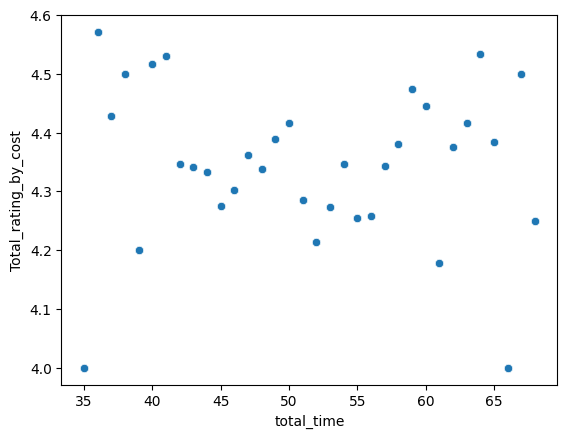

In [ ]:
df_foodhub_order['Total_rating_by_cost'] = df_foodhub_order.groupby('total_time')['rating'].transform('mean')
sns.scatterplot(data=df_foodhub_order, y='Total_rating_by_cost', x='total_time')
plt.show()

### Observations:
*  Best rating zones: 36–41 mins, 64–66 mins
*  Most stable zone: 42–57 mins
*  Worst points: 35 mins, 65–67 mins
*  Conclusion: Delivery time does not strongly impact rating

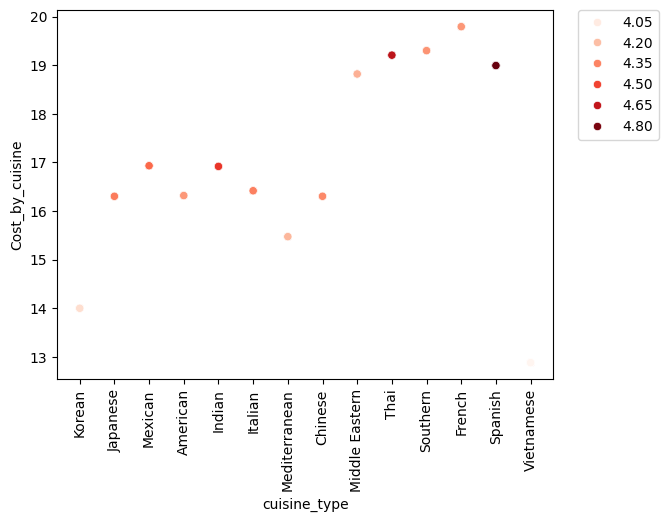

In [ ]:
df_foodhub_order['Cost_by_cuisine'] = df_foodhub_order.groupby('cuisine_type')['cost_of_the_order'].transform('mean')
sns.scatterplot(data=df_foodhub_order, y='Cost_by_cuisine', x='cuisine_type', hue='Total_rating_by_Cuisine', palette="Reds")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

### Observations:

*  Premium pricing cuisines: French, Thai, Spanish, Middle Eastern, Southern
*  Avergae pricing: Mexican, Indian, Italian, Japanese, Chinese, American
*  low pricing: Vietnamese, Korean
*  Insight: Higher cost cuisines tend to have higher ratings

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Write the code here

# Filtering out the orders where ratings were not given, then changing the rating column to float

df_rating = df_foodhub_order[df_foodhub_order['rating'] != 'Not given'].astype({'rating':'float'})

# checking rating count and average of each restaurant wise
df_rating = df_rating.groupby('restaurant_name').agg(rating_count=('rating','count'),rating_avg=('rating','mean')).reset_index()

# Condition for a rating count of more than 50 and the average rating should be greater than 4
condition = "(rating_count > 50) and (rating_avg > 4)"

promo_eligible_restaurants = df_rating.query(condition)
print(promo_eligible_restaurants)
print("Promo eligible restaurants are:",promo_eligible_restaurants['restaurant_name'].to_list())

               restaurant_name  rating_count  rating_avg
20   Blue Ribbon Fried Chicken            64    4.328125
21           Blue Ribbon Sushi            73    4.219178
136                Shake Shack           133    4.278195
153          The Meatball Shop            84    4.511905
Promo eligible restaurants are: ['Blue Ribbon Fried Chicken', 'Blue Ribbon Sushi', 'Shake Shack', 'The Meatball Shop']


#### Observations:
Promo eligible restaurants are:
*['Blue Ribbon Fried Chicken', 'Blue Ribbon Sushi', 'Shake Shack', 'The Meatball Shop']*

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Total value of orders more than $20
total_order_value_more_than_20 = df_foodhub_order[(df_foodhub_order['cost_of_the_order'] > 20)]['cost_of_the_order'].sum()
print(round(total_order_value_more_than_20,2))

# Company charges 25% of Total value of orders more than $20
revenue_more_than_20 = total_order_value_more_than_20 * 0.25
print(round(revenue_more_than_20,2))

# Total va;ue of orders more than $5 but less than $20
total_order_value_more_than_5 = df_foodhub_order[((df_foodhub_order['cost_of_the_order'] > 5) & (df_foodhub_order['cost_of_the_order'] <= 20))]['cost_of_the_order'].sum()
print(round(total_order_value_more_than_5,2))

# Company charges 15% of Total value of orders between $5 to $20
revenue_more_than_5 = total_order_value_more_than_5 * 0.15
print(round(revenue_more_than_5,2))

# Total revenue generated by the company across all orders
net_revenue = revenue_more_than_20 + revenue_more_than_5
print(f'Total revenue generated by the company across all orders ${round(net_revenue,2)}')


14754.91
3688.73
16517.17
2477.58
Total revenue generated by the company across all orders $6166.3


#### Observations:

Total revenue generated by the company across all orders $6166.3

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here
# Total Order count
total_number_of_orders = df_foodhub_order.shape[0]
print("Total number of orders:",total_number_of_orders)

# Total number of orders took more than 60 minutes of time
total_number_of_orders_more_than_60_minutes = ((df_foodhub_order['food_preparation_time']+df_foodhub_order['delivery_time'])>60).sum()
print(total_number_of_orders_more_than_60_minutes)

# % of more than 60 minutes order w.r.t Total orders
percentage_of_orders_more_than_60_minutes = (total_number_of_orders_more_than_60_minutes/total_number_of_orders)*100
print(f'Percentage of orders took more than 60 minutes {round(percentage_of_orders_more_than_60_minutes,2)}%')


Total number of orders: 1898
200
Percentage of orders took more than 60 minutes 10.54%


#### Observations:
Percentage of orders took more than 60 minutes 10.54%

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here

df_daywise_delivery_time = df_foodhub_order.groupby('day_of_the_week')['delivery_time'].mean()
print("Average delivery time during weekdays:",round(df_daywise_delivery_time['Weekday'],2))
print("Average delivery time during weekends:",round(df_daywise_delivery_time['Weekend'],2))
print("Difference in mean delivery time:",round((df_daywise_delivery_time['Weekday']-df_daywise_delivery_time['Weekend']),2))

Average delivery time during weekdays: 28.34
Average delivery time during weekends: 22.47
Difference in mean delivery time: 5.87


#### Observations:

*   Average delivery time during weekdays: 28.34 Minute
*   Average delivery time during weekends: 22.47 Minute
*   Usually deliver time in weekdays are higher than weekend by 5.87 Minute

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:


1.   Weekend orders are significantly higher than weekday orders
2.   American, Japanese, Italian, and Chinese cuisines have more order
3.   Korean, Thai, Vietnamese, Spanish, and French have very low demand
4.   Cost of orders is concentrated between $12–$22 with a right-skewed distribution
5.   Weekday delivery times are slightly higher than weekends
6.   Highest satisfaction: Spanish, Thai, Indian
7.   Most consistent: Mexican, Japanese, Italian
8.   Improvement needed: Vietnamese, Korean, Mediterranean
9.   Scale-quality gap: Chinese, Middle Eastern
10.  A large portion of orders have missing ratings ("Not given")
11.  Higher cost cuisines tend to have higher ratings



### Recommendations:

*  Focus more on weekends with offers or extra.
*  Promote American, Japanese, Italian, and Chinese cuisines more
*  Improve Vietnamese, Korean, and Mediterranean food quality and menus
*  Market Spanish, Thai, and Indian as premium options
*  Keep delivery time around 45–60 minutes, especially on weekdays
*  Encourage customers to give ratings.
*  Track and improve low-rated restaurants (Below 3.8)
*  Keep most prices between ₹12–₹22 and test higher pricing for premium cuisines
*  Improve quality for Chinese and Middle Eastern without reducing order volume